#### Chaimaa Faouzi, Master Génie Logiciel pour le Cloud Computing

### * Régression simple : 

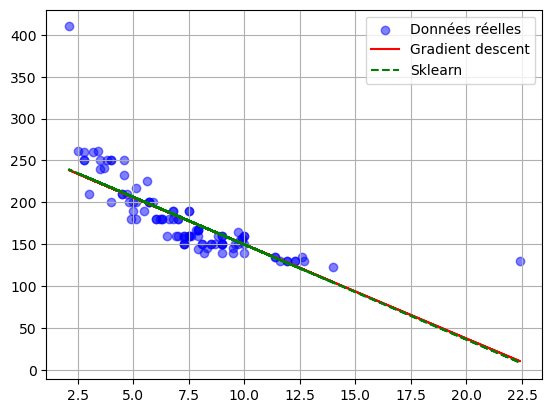

In [106]:
# 1. Import des bibliothèques
import pandas as pd  # Pour lire et manipuler les données
import numpy as np   # Pour les calculs numériques (matrices, vecteurs)
import matplotlib.pyplot as plt   # Pour afficher les graphiques
from sklearn.linear_model import LinearRegression  # Modèle de régression linéaire

# 2. Chargement des données
data = pd.read_csv("Desktop/TP_ML/ElectricCarData_Clean.csv")
X = data[['AccelSec']].values  #On récupère la variable indépendante "accélération" et transforme le vecteur en colonne (matrice)
y = data['TopSpeed_KmH'].values.reshape(-1, 1)    #On récupère la variable dépendante "vitesse max" et transforme le vecteur en colonne (matrice)

# 3. Ajouter biais 
X_b = np.c_[np.ones(len(X)), X]  #ajout d'une colonne de 1 pour intégrer le biais (β₀) dans le vecteur β

# 4. Initialisation des coefficients (β0, β1) à zéro
beta = np.zeros((2, 1))

# 5. Fonction de descente de gradient
def gradient_descent(X, y, beta, alpha=0.001, iterations=40000):   #alpha est la vitesse d'apprentissag
    m = len(y)  # m représente le nombre d'exemples dans le dataset
    for i in range(iterations):   # Boucle pour répéter la mise à jour des paramètres
        gradient = (1/m) * X.T.dot(X.dot(beta) - y)
        # X.dot(beta) - y : erreur entre la prédiction et la valeur réel
        # X.T.dot(...) : somme pondérée des erreurs pour chaque coefficient
        beta = beta - alpha * gradient   # Mise à jour des coefficients β pour réduire l’erreur return beta
    
    return beta  # retourne les paramètres optimisés

# 6. Entraînement
beta = gradient_descent(X_b, y, beta)  # on applique la descente de gradient pour trouver les meilleurs β
b0, b1 = beta[0][0], beta[1][0]  # récupération des vrais coefficients

# 7. Prédiction
y_pred_manuel = b0 + b1 * X  # On calcule les valeurs prédites à partir du l'échelle originale 

# 8. Régression avec sklearn
model = LinearRegression()
model.fit(X, y)  # entraînement du modèle sur les données (X, y)

# 9. Prédiction 
y_pred_sk = model.predict(X)  # apprentissage sur données brutes

# 10. Visualisation 
plt.scatter(X, y, color='blue', alpha=0.5, label='Données réelles')  # Nuage de points des données réelles
plt.plot(X, y_pred_manuel, 'r', label='Gradient descent')  # Droite du modèle from scratch (descente de gradient)
plt.plot(X, y_pred_sk, 'g--', label='Sklearn') # Droite du modèle scikit-learn (en pointillés)
plt.legend()
plt.grid()
plt.show()

### * Régression multiple : 

In [108]:
# 1. Variables explicatives (X) et cible (y)
X = data[['AccelSec', 'Range_Km']].values  # X contient les variables d'entrée utilisées pour la prédiction
y = data['TopSpeed_KmH'].values  # y contient la variable à prédire (valeur réelle)

# 2. Ajout du biais
X_b = np.c_[np.ones(len(X)), X]  #ajout d'une colonne de 1 pour intégrer le biais (β₀) dans le vecteur β

# 3. Initialisation des paramètres (coefficients β)
beta = np.zeros((X_b.shape[1], 1))
y = y.reshape(-1, 1)   # Transformation de y en vecteur colonne pour les calculs matriciels

# 4. Fonction de descente de gradient
def gradient_descent(X, y, beta, alpha=0.00001, iterations=50000):   #alpha est la vitesse d'apprentissag
    m = len(y)  # m représente le nombre d'exemples dans le dataset
    for i in range(iterations):   # Boucle pour répéter la mise à jour des paramètres
        gradient = (1/m) * X.T.dot(X.dot(beta) - y)
        # X.dot(beta) - y : erreur entre la prédiction et la valeur réel
        # X.T.dot(...) : somme pondérée des erreurs pour chaque coefficient
        beta = beta - alpha * gradient   # Mise à jour des coefficients β pour réduire l’erreur return beta
    
    return beta  # retourne les paramètres optimisés    

# 5. Entraînement 
beta = gradient_descent(X_b, y, beta)   # on applique la descente de gradient pour trouver les meilleurs β
y_pred_manuel = X_b.dot(beta)  # Prédictions avec le modèle entraîné

# 6. Régression avec sklearn 
model = LinearRegression().fit(X, y)  # sklearn entraîne automatiquement le modèle
y_pred_sk = model.predict(X)  # apprentissage sur données brutes

### * Régression polynomiale : 

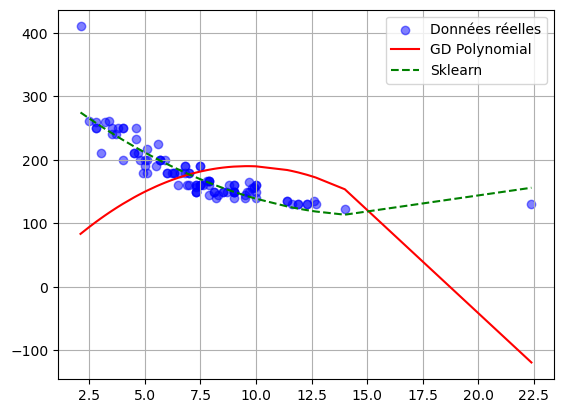

In [110]:
# 1. Variables explicatives (X) et cible (y)
X = data[['AccelSec']].values  # X contient une seule variable d'entrée
y = data['TopSpeed_KmH'].values.reshape(-1, 1)  # y contient la variable à prédire (transformée en vecteur colonne)

# 2. Création des features polynomiales (X et X²)
X_poly = np.c_[X, X**2]
# On ajoute une nouvelle variable X² pour modéliser une relation non linéaire
# Le modèle devient : y = β0 + β1*X + β2*X²

# 3. Ajout du biais
X_b = np.c_[np.ones(len(X)), X_poly] # Ajout d'une colonne de 1 pour intégrer le biais β0 dans les calculs matriciels

# 4. Initialisation
beta = np.zeros((X_b.shape[1], 1))   # beta contient les paramètres (β0, β1, β2), initialisés à 0

# 5. Descente de gradient
def gradient_descent(X, y, beta, alpha=0.00001, iterations=50000):   #alpha est la vitesse d'apprentissag
    m = len(y)  # m représente le nombre d'exemples dans le dataset
    for i in range(iterations):   # Boucle pour répéter la mise à jour des paramètres
        gradient = (1/m) * X.T.dot(X.dot(beta) - y)
        # X.dot(beta) - y : erreur entre la prédiction et la valeur réel
        # X.T.dot(...) : somme pondérée des erreurs pour chaque coefficient
        beta = beta - alpha * gradient   # Mise à jour des coefficients β pour réduire l’erreur return beta
    
    return beta  # retourne les paramètres optimisés    

# 6. Entraînement 
beta = gradient_descent(X_b, y, beta)  # Optimisation des paramètres avec la descente de gradient
y_pred_manuel = X_b.dot(beta)  # Calcul des prédictions finales : y = X_b × beta

# 7. Régression avec sklearn 
model = LinearRegression().fit(X_poly, y)  # sklearn apprend automatiquement β0, β1 et β2
y_pred_sk = model.predict(X_poly)  # Prédictions du modèle sklearn

# 8. Visualisation
plt.scatter(X, y, color='blue', alpha=0.5, label='Données réelles')
plt.plot(X_sorted, y_man_sorted, color='red', label='GD Polynomial')
plt.plot(X_sorted, y_sk_sorted, '--', color='green', label='Sklearn')
plt.legend()
plt.grid()
plt.show()

### * Régression logistique : 

Theta final: [-1.32548794  0.53393634]


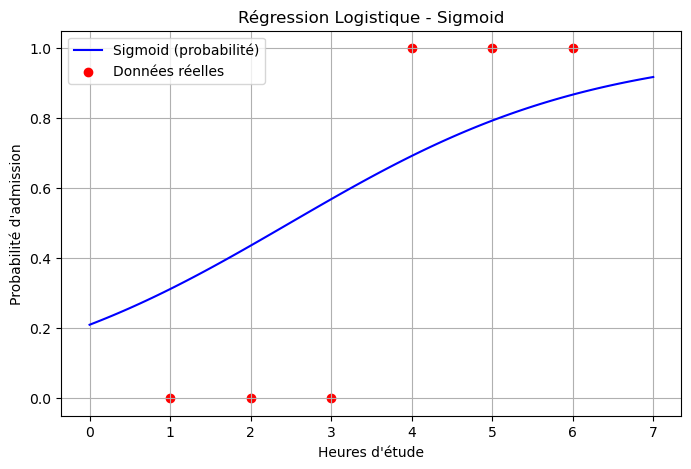

In [114]:
# 1. DATASET (simple)
# X = variable d'entrée (ici : heures d'étude)
# chaque ligne = un exemple
X = np.array([
    [1],  # 1 heure
    [2],  # 2 heure
    [3],  # 3 heure
    [4],  # 4 heure
    [5],  # 5 heure
    [6]   # 6 heure
])

# y = résultats attendus (0 = non admis, 1 = admis)
y_class = np.array([0, 0, 0, 1, 1, 1])

# 2. Fonction Sigmoid
def sigmoid(z):  # transforme un nombre réel en probabilité (entre 0 et 1)
    return 1 / (1 + np.exp(-z))

# 3. Ajout du biais 
X_b = np.c_[np.ones((len(X), 1)), X]  # on ajoute une colonne de 1 pour représenter θ0

# 4. Initialisation des paramètres
theta = np.zeros(X_b.shape[1])   # theta = paramètres du modèle (θ0, θ1)
learning_rate = 0.01  # taux d'apprentissage (taille des pas de correction)
m = len(y_class)   # nombre d'exemples dans le dataset
 
# 5. Descente de gradient
for i in range(1000):   # on répète 1000 fois pour apprendre
    z = X_b.dot(theta)  # calcul linéaire : z = θ0 + θ1*x
    h = sigmoid(z)   # application de la sigmoid → probabilité entre 0 et 1

    gradient = (X_b.T.dot(h - y_class)) / m   # calcul du gradient
    theta -= learning_rate * gradient  # mise à jour des paramètres

print("Theta final:", theta)  # affichage des paramètres appris

# 6. Prediction (z = theta0 + theta1*x)
x_values = np.linspace(0, 7, 100)   # on crée des valeurs continues pour dessiner la courbe
X_plot = np.c_[np.ones(len(x_values)), x_values]   # on ajoute le biais → [1, x]
z = X_plot.dot(theta)  # calcul de z pour chaque x
y_prob = sigmoid(z)  # transformation en probabilité

# 7. Visualisation 
plt.figure(figsize=(8,5))
plt.plot(x_values, y_prob, label="Sigmoid (probabilité)", color="blue")  # courbe sigmoid (probabilités)
plt.scatter(X, y_class, color="red", label="Données réelles")  # points réels
plt.xlabel("Heures d'étude")
plt.ylabel("Probabilité d'admission")
plt.title("Régression Logistique - Sigmoid")
plt.legend()
plt.grid()  # grille pour mieux lire
plt.show()